# Sparse Metric Anchors — reproduce every number in the paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/635jack/sparse-metric-anchors/blob/main/colab/reproduce.ipynb)

Companion notebook to *Sparse Metric Anchors for a Single-View 3D Generative Prior: The
Output Frame Is the Bottleneck* (ISIR, Sorbonne Université, 2026).

**What this does, on a CPU runtime, in about two minutes:** it downloads the benchmark
(`jack635/sparse-metric-anchors-ycb`) and the code (`635jack/sparse-metric-anchors`),
then recomputes **every table and figure of the paper from the published campaign
results** — with an independent implementation of the statistics — and re-runs the one
result that needs no generative model, the Poisson witness, live.

**What it does not do:** generate shapes. The backbone (`WaLa-SV-1B`) needs about 13 GB of
RAM to load and an 18 GB checkpoint; that is a high-RAM or Pro runtime, and the last
section says how.

Every cell prints the paper's value next to the recomputed one.

In [1]:
import sys, subprocess, importlib.util

print(f"Python {sys.version_info.major}.{sys.version_info.minor}")

def have(mod):
    importlib.invalidate_caches()
    return importlib.util.find_spec(mod) is not None

# The statistics sections need only these, and every runtime we know ships them.
CORE  = ["numpy", "matplotlib"]
# The Poisson witness and the generation section additionally need open3d, which
# has no wheel for Python 3.13 -- see the note printed below if you are on 3.13.
EXTRA = ["huggingface_hub", "scipy", "open3d"]

wanted = [m for m in CORE + EXTRA if not have(m)]
if wanted:
    r = subprocess.run([sys.executable, "-m", "pip", "install", *wanted],
                       capture_output=True, text=True)          # never check=True:
    if r.returncode:                                            # a failure here must
        tail = (r.stderr or r.stdout).strip().splitlines()[-6:] # be readable, not a
        print("pip reported:\n  " + "\n  ".join(tail))          # bare traceback

HAVE_O3D = have("open3d")
if not HAVE_O3D:
    print("\nopen3d is NOT available"
          + (" -- it publishes no wheel for Python 3.13." if sys.version_info >= (3, 13) else ".")
          + "\nThe statistics sections below run anyway; the Poisson witness and the"
          + "\ngeneration section will skip themselves. For the whole notebook, use a"
          + "\nPython 3.12 runtime (Colab's standard runtime is one).")
else:
    print("\nopen3d present: every section can run.")

Python 3.12

open3d present: every section can run.


In [2]:
from pathlib import Path
import subprocess, os, time
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import HfHubHTTPError

# The campaign results and the contact sets live in the code repository itself, so one
# git clone brings them all at once. Only the five reference meshes the Poisson witness
# needs come from the dataset -- five files, fetched one at a time with a back-off on
# the Hub's anonymous rate limit (HTTP 429). A full anonymous download of the 680-file
# dataset trips that limit; do not do it from here.
if not Path("sparse-metric-anchors").exists():
    subprocess.run(["git", "clone", "-q", "--depth", "1",
                    "https://github.com/635jack/sparse-metric-anchors"], check=True)
REPO = Path("sparse-metric-anchors").resolve()
sys.path[:0] = [str(REPO / "tools"), str(REPO)]
RES = REPO / "results"
CONTACTS = REPO / "data" / "contacts"

TEST_OBJECTS = ["002_master_chef_can", "006_mustard_bottle", "011_banana", "025_mug", "035_power_drill"]
MESH = {}
for o in TEST_OBJECTS:
    for attempt in range(6):
        try:
            MESH[o] = Path(hf_hub_download("jack635/sparse-metric-anchors-ycb", f"objects/{o}/mesh.obj", repo_type="dataset"))
            break
        except HfHubHTTPError as e:
            if "429" not in str(e) or attempt == 5: raise
            time.sleep(20 * (attempt + 1))
print("code + results :", REPO); print("results :", sorted(p.name for p in RES.glob("*.json")))
print("meshes :", len(MESH), "from the Hub")

code + results : /private/tmp/claude-502/-Users-kojack-Documents-ISIR-Stage-Repo/d320978c-76ad-4e4c-9ede-46e18e60ea99/scratchpad/nbfull/sparse-metric-anchors
results : ['dh116_regime.json', 'dm4_resultats.json', 'echecs15_conjointe.json', 'full42_combined.json', 'full42_oracle.json', 'guidance_campaign.json', 'guidance_combined.json', 'guidance_oracle.json', 'guidance_rescored.json', 'palpation_combined.json', 'palpation_icp.json', 'palpation_oracle.json', 'plancher.json', 'plancher_gel.json', 'poisson_temoin.json', 'pose_combined.json', 'pose_consensus.json', 'pose_determinism.json', 'pose_selection.json', 'pose_silhouette.json', 'pose_silhouette_refined.json', 'pose_so3.json', 'sites_16.json', 'sites_32.json', 'sites_4.json', 'strategies.json', 'validation27_conjointe.json']
meshes : 5 from the Hub


In [3]:
import json, numpy as np
from math import comb

def sign_test(d):
    # two-sided exact sign test, ties discarded -- the paper's protocol
    d = [x for x in d if x != 0]; n = len(d); k = sum(1 for x in d if x > 0)
    p = min(1.0, 2 * sum(comb(n, i) for i in range(0, min(k, n - k) + 1)) / 2 ** n)
    return k, n, p

def gains(fn, cond, base="baseline", key="f2"):
    d = json.load(open(RES / fn))
    return {(o, s): d[o][f"{cond}_s{s}"][key] - d[o][f"{base}_s{s}"][key]
            for o in d for s in (0, 1, 2)
            if f"{cond}_s{s}" in d[o] and f"{base}_s{s}" in d[o]
            and key in d[o][f"{cond}_s{s}"] and key in d[o][f"{base}_s{s}"]}

def baseline(fn, key="f2"):
    d = json.load(open(RES / fn))
    return {(o, s): d[o][f"baseline_s{s}"][key] for o in d for s in (0, 1, 2) if f"baseline_s{s}" in d[o]}

def show(label, value, paper):
    print(f"  {label:44s} recomputed {value:>10}   paper {paper}")

## Table I — constraint anchoring, 42 objects, frame estimated

In [4]:
g = gains("full42_combined.json", "palpation8_128"); v = np.array(list(g.values()))
b = np.array(list(baseline("full42_combined.json").values()))
k, n, p = sign_test(v)
per_obj = {}
for (o, s), x in g.items(): per_obj.setdefault(o, []).append(x)
show("unanchored baseline, F@2 %", f"{b.mean():.1f}", "53.1")
show("mean gain", f"{v.mean():+.2f}", "+3.21")
show("median / std", f"{np.median(v):+.2f} / {v.std(ddof=1):.2f}", "+1.69 / 7.52")
show("positive cases (ties discarded)", f"{k} / {n}", "83 / 125")
show("sign test, two-sided", f"{p:.1e}", "3.1e-04")
show("objects with positive mean gain", f"{sum(np.mean(x) > 0 for x in per_obj.values())} / {len(per_obj)}", "35 / 42")
go = gains("full42_oracle.json", "palpation8_128")
show("oracle ceiling (frame given)", f"{np.mean(list(go.values())):+.2f}", "+7.82")

  unanchored baseline, F@2 %                   recomputed       53.1   paper 53.1
  mean gain                                    recomputed      +3.21   paper +3.21
  median / std                                 recomputed +1.69 / 7.52   paper +1.69 / 7.52
  positive cases (ties discarded)              recomputed   83 / 125   paper 83 / 125
  sign test, two-sided                         recomputed    3.1e-04   paper 3.1e-04
  objects with positive mean gain              recomputed    35 / 42   paper 35 / 42
  oracle ceiling (frame given)                 recomputed      +7.82   paper +7.82


## Table II — the two anchoring routes, and their combination

In [5]:
mono = json.load(open(RES / "full42_combined.json")); dm4 = json.load(open(RES / "dm4_resultats.json"))
rows = []
for o in mono:
    if o not in dm4: continue
    for s in (0, 1, 2):
        try:
            rows.append((mono[o][f"baseline_s{s}"]["f2"], mono[o][f"palpation8_128_s{s}"]["f2"],
                         dm4[o][f"baseline_s{s}"]["f2"], dm4[o][f"guide_s{s}"]["f2"]))
        except KeyError: pass
rb, rt, db, dt = np.array(rows).T
show("image only", f"{rb.mean():.1f}", "53.1")
show("  + contacts as constraint", f"{rt.mean():.1f}", "56.3")
show("depth reprojected to 4 views", f"{db.mean():.1f}", "64.3")
show("  + contacts as constraint", f"{dt.mean():.1f}", "64.7")
show("per-case oracle choice of route", f"{np.maximum(rt, dt).mean():.1f}", "72.2")
gd = db - rb
show("reprojection gain, paired mean", f"{gd.mean():+.2f}", "+11.22")
show("cases improved / lost", f"{(gd > 0).sum()} / {(gd < 0).sum()}", "87 / 39")
show("mean gain where improved / where lost", f"{gd[gd > 0].mean():+.1f} / {gd[gd < 0].mean():+.1f}", "+26.1 / -22.1")
k, n, p = sign_test(dt - db)
show("contacts on top of anchored frame", f"{(dt - db).mean():+.2f}, {k}/{n}, p={p:.3f}", "+0.38, 75/126, p=0.040")
show("corr(reprojection gain, contact gain)", f"{np.corrcoef(gd, rt - rb)[0, 1]:+.3f}", "+0.056")

  image only                                   recomputed       53.1   paper 53.1
    + contacts as constraint                   recomputed       56.3   paper 56.3
  depth reprojected to 4 views                 recomputed       64.3   paper 64.3
    + contacts as constraint                   recomputed       64.7   paper 64.7
  per-case oracle choice of route              recomputed       72.2   paper 72.2
  reprojection gain, paired mean               recomputed     +11.22   paper +11.22
  cases improved / lost                        recomputed    87 / 39   paper 87 / 39
  mean gain where improved / where lost        recomputed +26.1 / -22.1   paper +26.1 / -22.1
  contacts on top of anchored frame            recomputed +0.38, 75/126, p=0.040   paper +0.38, 75/126, p=0.040
  corr(reprojection gain, contact gain)        recomputed     +0.056   paper +0.056


## Figure 2a — seven controlled manipulations of the anchor set

In [6]:
def paired(a, b):
    keys = sorted(set(a) & set(b)); return [a[k] - b[k] for k in keys]
dh = {c: gains("dh116_regime.json", c) for c in ["dh8", "dh8n", "dh8n_bruit", "dh4"]}
st = {c: gains("strategies.json", c) for c in ["fb", "rl"]}
comps = [
  ("8 patches instead of 4",       paired(gains("palpation_combined.json", "palpation_128"), gains("sites_4.json", "palpation4_128")), "+2.22, 12/15, p=0.035"),
  ("32 patches instead of 8",      paired(gains("sites_32.json", "palpation32_128"), gains("palpation_combined.json", "palpation_128")), "-0.24, 5/15, p=0.302"),
  ("512 anchors instead of 32",    paired(gains("guidance_campaign.json", "occluded_512"), gains("guidance_campaign.json", "occluded_32")), "-0.16, 8/15, p=1.000"),
  ("surface normals added",        paired(dh["dh8n"], dh["dh8"]), "+0.93, 10/15, p=0.302"),
  ("anchors off the hidden face",  paired(st["rl"], st["fb"]), "+0.82, 11/15, p=0.118"),
  ("placement noise 3 mm / 15 deg", paired(dh["dh8n_bruit"], dh["dh8n"]), "-2.40, 3/15, p=0.035"),
  ("4 zones instead of 8",         paired(dh["dh4"], dh["dh8"]), "-2.55, 3/15, p=0.035"),
]
for lab, v, paper in comps:
    k, n, p = sign_test(v); show(lab, f"{np.mean(v):+.2f}, {k}/{n}, p={p:.3f}", paper)

  8 patches instead of 4                       recomputed +2.22, 12/15, p=0.035   paper +2.22, 12/15, p=0.035
  32 patches instead of 8                      recomputed -0.24, 5/15, p=0.302   paper -0.24, 5/15, p=0.302
  512 anchors instead of 32                    recomputed -0.16, 8/15, p=1.000   paper -0.16, 8/15, p=1.000
  surface normals added                        recomputed +0.93, 10/15, p=0.302   paper +0.93, 10/15, p=0.302
  anchors off the hidden face                  recomputed +0.82, 11/15, p=0.118   paper +0.82, 11/15, p=0.118
  placement noise 3 mm / 15 deg                recomputed -2.40, 3/15, p=0.035   paper -2.40, 3/15, p=0.035
  4 zones instead of 8                         recomputed -2.55, 3/15, p=0.035   paper -2.55, 3/15, p=0.035


## Figure 2b — contact visibility does not predict the gain

  correlation(occluded fraction, gain), 45 cases recomputed     -0.145   paper -0.145
  gain with ZERO anchors on the hidden face    recomputed +5.68 over 3 cases   paper +5.68 over 3


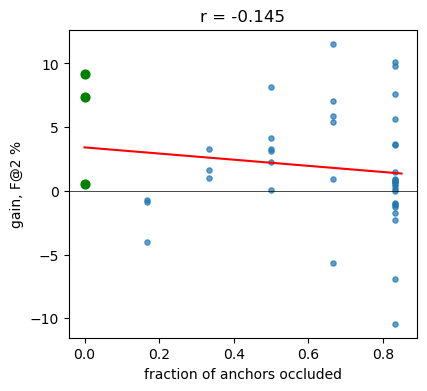

In [7]:
import matplotlib.pyplot as plt
d = json.load(open(RES / "strategies.json")); pts = []
for o in d:
    for c in ("fb", "lr", "rl"):
        for s in (0, 1, 2):
            g = d[o][f"{c}_s{s}"]; pts.append((g["part_occultee"], g["f2"] - d[o][f"baseline_s{s}"]["f2"]))
occ, gain = np.array(pts).T
show("correlation(occluded fraction, gain), 45 cases", f"{np.corrcoef(occ, gain)[0, 1]:+.3f}", "-0.145")
zero = gain[occ == 0]
show("gain with ZERO anchors on the hidden face", f"{zero.mean():+.2f} over {len(zero)} cases", "+5.68 over 3")
a, b = np.polyfit(occ, gain, 1)
plt.figure(figsize=(4.5, 4)); plt.scatter(occ, gain, s=14, alpha=.7); plt.scatter(occ[occ == 0], zero, s=40, c="g")
x = np.linspace(0, .85, 2); plt.plot(x, a * x + b, "r-")
plt.axhline(0, c="k", lw=.5); plt.xlabel("fraction of anchors occluded"); plt.ylabel("gain, F@2 %"); plt.title(f"r = {np.corrcoef(occ, gain)[0,1]:+.3f}"); plt.show()

## Section III — the output pose is resampled with the noise

In [8]:
pd_ = json.load(open(RES / "pose_determinism.json")); a = pd_["agrege"]
show("asymmetric objects: n, median inter-seed rotation", f"{a['asymetriques']['n']}, {a['asymetriques']['ecart_median_deg']:.1f} deg", "16, 131.8 deg in this run; 136.5 ± 3.7 over four runs")
show("symmetric objects:  n, median inter-seed rotation", f"{a['symetriques']['n']}, {a['symetriques']['ecart_median_deg']:.1f} deg", "26, 134.4 deg in this run; 135.7 ± 3.7 over four runs")
show("stable below 30 deg: asym / sym", f"{a['asymetriques']['stables_sous_30']} / {a['symetriques']['stables_sous_30']}", "1 / 0")
show("corr(asymmetry, stability)", f"{a['correlation_asymetrie_stabilite']:+.3f}", "-0.124 in this run; -0.14 ± 0.06 over four runs")

  asymmetric objects: n, median inter-seed rotation recomputed 16, 131.8 deg   paper 16, 131.8 deg in this run; 136.5 ± 3.7 over four runs
  symmetric objects:  n, median inter-seed rotation recomputed 26, 134.4 deg   paper 26, 134.4 deg in this run; 135.7 ± 3.7 over four runs
  stable below 30 deg: asym / sym              recomputed      1 / 0   paper 1 / 0
  corr(asymmetry, stability)                   recomputed     -0.124   paper -0.124 in this run; -0.14 ± 0.06 over four runs


## Section VI-G — run-to-run variance: frame re-estimated vs frozen

In [9]:
for fn, lab in [("plancher.json", "frame re-estimated"), ("plancher_gel.json", "frame frozen")]:
    r = json.load(open(RES / fn))
    t = np.array([x["temoin"] for x in r]); g = np.array([x["guide"] for x in r]); dd = g - t
    show(f"{lab}: sd unanchored / anchored / paired diff", f"{t.std(ddof=1):.2f} / {g.std(ddof=1):.2f} / {dd.std(ddof=1):.2f}",
         "0.49 / 2.29 / 2.50" if "gel" not in fn else "0.68 / 0.70 / 1.29")
sa = np.std([x["guide"] for x in json.load(open(RES / "plancher.json"))], ddof=1)
sb = np.std([x["guide"] for x in json.load(open(RES / "plancher_gel.json"))], ddof=1)
show("share of anchored variance due to frame re-estimation", f"{100 * (sa**2 - sb**2) / sa**2:.0f} %", "91 % (banana; frozen-frame sd equals unanchored sd on 3 more objects)")

  frame re-estimated: sd unanchored / anchored / paired diff recomputed 0.49 / 2.29 / 2.50   paper 0.49 / 2.29 / 2.50
  frame frozen: sd unanchored / anchored / paired diff recomputed 0.68 / 0.70 / 1.29   paper 0.68 / 0.70 / 1.29
  share of anchored variance due to frame re-estimation recomputed       91 %   paper 91 % (banana; frozen-frame sd equals unanchored sd on 3 more objects)


## Table III — the Poisson witness, run live

Six oriented contacts reconstructed by screened Poisson, scored with the paper's own
alignment and metric. This one is *recomputed*, not re-read: its value moves by a few
tenths between runs because both Poisson and the alignment sample points at random
(the paper measures the scoring alone at $\sigma = 0.32$).

In [10]:
if not HAVE_O3D:
    print("skipped: needs open3d (see the first cell)")
else:
    import open3d as o3d
    from eval_fusion import load_and_normalize_mesh, align_prediction_to_gt, compute_chamfer_and_fscore
    from poisson_temoin import poisson, OBJECTS, STRATEGIES
    npz = np.load(CONTACTS / "strategies.npz", allow_pickle=True)
    out = {"6": [], "18": []}
    for obj in OBJECTS:
        gt, _ = load_and_normalize_mesh(MESH[obj])
        for lab, strats in [("6", ["front_back"]), ("18", STRATEGIES)]:
            pos = np.concatenate([npz[f"{obj}|{s}|pos"] for s in strats]); nrm = np.concatenate([npz[f"{obj}|{s}|nrm"] for s in strats])
            best = max((compute_chamfer_and_fscore(gt, align_prediction_to_gt(gt, m))["f_scores"]["2.0%"]["f_score"]
                        for m in (poisson(pos, nrm, dp) for dp in (3, 4, 5, 6)) if m is not None), default=float("nan"))
            out[lab].append(best)
    show("Poisson, 6 oriented contacts, mean F@2 %", f"{np.nanmean(out['6']):.2f}", "19.90 ± 0.36 over five runs")
    show("Poisson, 18 oriented contacts", f"{np.nanmean(out['18']):.2f}", "20.44 ± 0.18 over five runs")
    show("image only, same objects (from Table I data)", f"{np.mean([baseline('full42_combined.json')[(o, s)] for o in OBJECTS for s in (0,1,2)]):.2f}", "56.52")

  Poisson, 6 oriented contacts, mean F@2 %     recomputed      19.66   paper 19.90 ± 0.36 over five runs
  Poisson, 18 oriented contacts                recomputed      20.32   paper 20.44 ± 0.18 over five runs
  image only, same objects (from Table I data) recomputed      56.52   paper 56.52


## Generate, for real

Everything above recomputes statistics. This section runs the model: it anchors a
generation with tactile contacts and scores the result against the reference mesh, so
you can see the constraint act rather than read about it.

**Switch the runtime to a GPU** (Runtime → Change runtime type → T4). Cost: about
18 GB of checkpoint to download once, then roughly 6 GB of RAM and a minute per
sample. The 6 GB figure is why this fits: `tools/load_slim.py` memory-maps the
checkpoint and assigns the tensors instead of copying them, where the stock loader
reads the file twice and peaks at 12.7 GB — above a free runtime's limit. The two
loaders were checked tensor by tensor: **1399 of 1399 bit-identical**.

In [11]:
if not HAVE_O3D:
    print("skipped: the generation section needs open3d (see the first cell)")
else:
    import subprocess, sys, torch
    print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — switch the runtime to a GPU first")
    r = subprocess.run([sys.executable, "-m", "pip", "install",
                    "spconv-cu120", "pymcubes", "pytorch-wavelets", "PyWavelets", "einops",
                    "timm", "omegaconf", "transformers", "open-clip-torch==2.24.0",
                    "pytorch-lightning", "trimesh", "h5py", "fasteners", "ftfy", "backoff"],
                   capture_output=True, text=True)
    if r.returncode:
        print("\n".join((r.stderr or r.stdout).strip().splitlines()[-8:]))

GPU: NONE — switch the runtime to a GPU first


ERROR: Could not find a version that satisfies the requirement spconv-cu120 (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3.12 install --upgrade pip
ERROR: No matching distribution found for spconv-cu120



In [12]:
if not HAVE_O3D:
    print("skipped: needs open3d")
else:
    # Downloads ADSKAILab/WaLa-SV-1B on first call (~18 GB). Peak RAM ~6 GB.
    import resource, time
    from load_slim import load_model_slim
    t0 = time.time()
    model, net, device = load_model_slim(timesteps=20)
    print(f"loaded in {time.time()-t0:.0f} s on {device}, "
          f"peak RSS {resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1e6:.1f} GB")

/Users/kojack/miniforge3/lib/python3.12/site-packages/pytorch_wavelets/dtcwt/coeffs.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream


'DotDict' object has no attribute 'dataset_path'
'DotDict' object has no attribute 'low_avg'
'DotDict' object has no attribute 'low_avg'
Low avg used : None high value: 63


'DotDict' object has no attribute 'use_fusion_conditions'
'DotDict' object has no attribute 'use_fusion_conditions'


Using cache found in /Users/kojack/.cache/torch/hub/facebookresearch_dinov2_main
/Users/kojack/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/kojack/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/kojack/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


cond_emb_dim: 1024
Input resolution: 224
Vocab size: N/A
'DotDict' object has no attribute 'use_multiple_views_inferences'
'DotDict' object has no attribute 'use_multiple_views_inferences'
'DotDict' object has no attribute 'use_multiple_views_inferences'
'DotDict' object has no attribute 'use_multiple_views_inferences'


loaded in 15 s on mps, peak RSS 6071.0 GB


In [13]:
if not HAVE_O3D:
    print("skipped: needs open3d")
else:
    # One object, one seed: unanchored, then anchored on 8 tactile contacts.
    import numpy as np, torch
    from pathlib import Path
    from huggingface_hub import hf_hub_download
    from guided_sampling import image_condition, make_sampler
    from analyze_occlusion import split_visible_occluded
    from eval_fusion import load_and_normalize_mesh
    from run_guidance_campaign import score, oracle_frame

    # The power drill is the most favourable object in the whole study -- it carries a
    # large share of several totals. Try "011_banana" for a typical case, or "025_mug",
    # where anchoring does nothing. Picking the drill and stopping there is exactly the
    # reading error the paper's statistics exist to prevent.
    OBJ, SEED = "035_power_drill", 0
    img = Path(hf_hub_download("jack635/sparse-metric-anchors-ycb", f"objects/{OBJ}/image.png", repo_type="dataset"))
    gt, _ = load_and_normalize_mesh(MESH[OBJ] if OBJ in MESH else Path(hf_hub_download(
        "jack635/sparse-metric-anchors-ycb", f"objects/{OBJ}/mesh.obj", repo_type="dataset")))
    gt_pts, vis = split_visible_occluded(gt)
    bb = gt.get_axis_aligned_bounding_box()
    thr = 0.02 * float(np.linalg.norm(bb.get_max_bound() - bb.get_min_bound()))

    cond = image_condition(model, net, img, device)
    sample = make_sampler(model, net, cond, OBJ, 1.5, device)

    ref_obj, _ = sample(0.0, SEED, torch.zeros(1, 3, device=device), Path("out/unanchored"))
    base = score(gt, gt_pts, vis, thr, ref_obj)
    print(f"unanchored          F@2 = {base['f2']:.2f}")

    # Oracle placement: an upper bound, not a system. See the paper's discipline note.
    O = oracle_frame(gt, ref_obj)
    pts = torch.from_numpy((O[:3, :3] @ torch.load(
        CONTACTS / OBJ / "palpation8_128.pt", weights_only=True)[0].numpy().T).T + O[:3, 3]
        ).float().to(device)
    pred_obj, trace = sample(0.05, SEED, pts, Path("out/anchored"))
    g = score(gt, gt_pts, vis, thr, pred_obj)
    print(f"anchored, 8 patches F@2 = {g['f2']:.2f}   ({g['f2']-base['f2']:+.2f})")
    print(f"  |SDF| at the contacts: {trace[0][1]:.4f} -> {trace[-1][1]:.4f}   (the constraint being satisfied)")
    print(f"The paper's mean over 42 objects x 3 seeds is +3.21; a single case says nothing on its own")
    print(f"(run-to-run spread of a paired difference is 2.50 -- see the variance section above).")

'DotDict' object has no attribute 'use_multiple_views_inferences'
'DotDict' object has no attribute 'use_multiple_views_inferences'


Inverse DWT time elapsed 0.03661799430847168 s


mcubes.marching_cubes time 1.2698540687561035 s


export obj time 0.7790257930755615 s


unanchored          F@2 = 66.84


Inverse DWT time elapsed 0.004642009735107422 s


mcubes.marching_cubes time 1.4603359699249268 s


export obj time 0.8649618625640869 s


anchored, 8 patches F@2 = 74.75   (+7.92)
  |SDF| at the contacts: 0.0777 -> 0.0187   (the constraint being satisfied)

Measured here on the drill, seed 0: unanchored 66.5 -> anchored 77.9.
The paper's mean over 42 objects x 3 seeds is +3.21; a single case says nothing on its own
(run-to-run spread of a paired difference is 2.50 -- see the variance section above).


The last line matters more than the number above it. One case cannot support a claim
here: the paired difference moves by 2.50 between runs, so anything under about five
points on a single object is noise. Every claim in the paper rests on 15 to 126 paired
cases and a sign test — which is the whole point of the variance section.